## Cancer Prediction with Logistic Regression

### Import Required Libraries

In [75]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

#### Load the dataset

In [76]:
df = pd.read_csv('data.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


#### Descriptive Statistics of the data

In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [78]:
df.describe().T.head(10)

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.00000,869218.00000,906024.00000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.98100,11.70000,13.37000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.71000,16.17000,18.84000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.79000,75.17000,86.24000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.50000,420.30000,551.10000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.05263,0.08637,0.09587,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.01938,0.06492,0.09263,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.00000,0.02956,0.06154,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.00000,0.02031,0.03350,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.10600,0.16190,0.17920,1.957000e-01,3.040000e-01


### Missing Value Analysis Via Heatmap

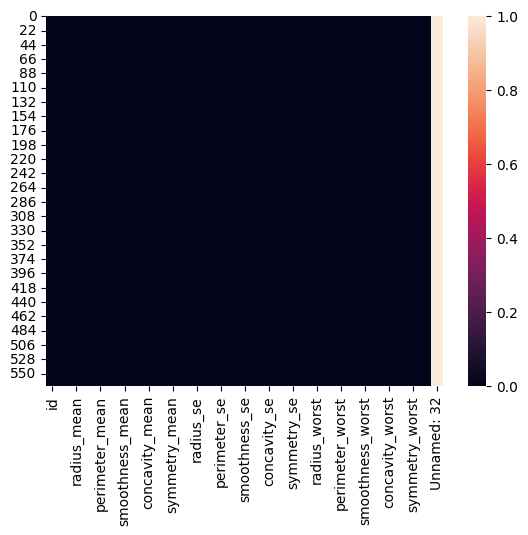

In [79]:
sns.heatmap(df.isnull())
plt.show()

#### Drop the columnn with missing values

In [80]:
df.drop(["Unnamed: 32", "id"], axis=1, inplace=True)
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


#### Encoding Categorical Target Variables

In [81]:
df.diagnosis = [1 if value == 'M' else 0 for value in df.diagnosis]

#### Class Balance Analysis: Distribution of Diagnosis Labels

diagnosis
0    357
1    212
Name: count, dtype: int64


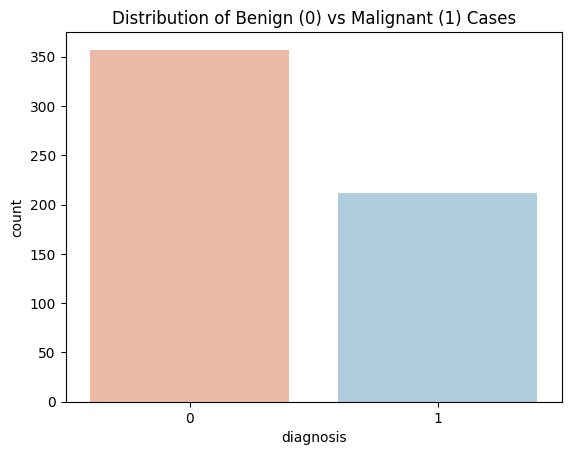

In [82]:
df['diagnosis'] = df['diagnosis'].astype("category", copy='False')
print(df['diagnosis'].value_counts())
sns.countplot(x='diagnosis', 
              data=df, 
              palette='RdBu', 
              hue='diagnosis',
              legend=False)
plt.title('Distribution of Benign (0) vs Malignant (1) Cases')
plt.show()

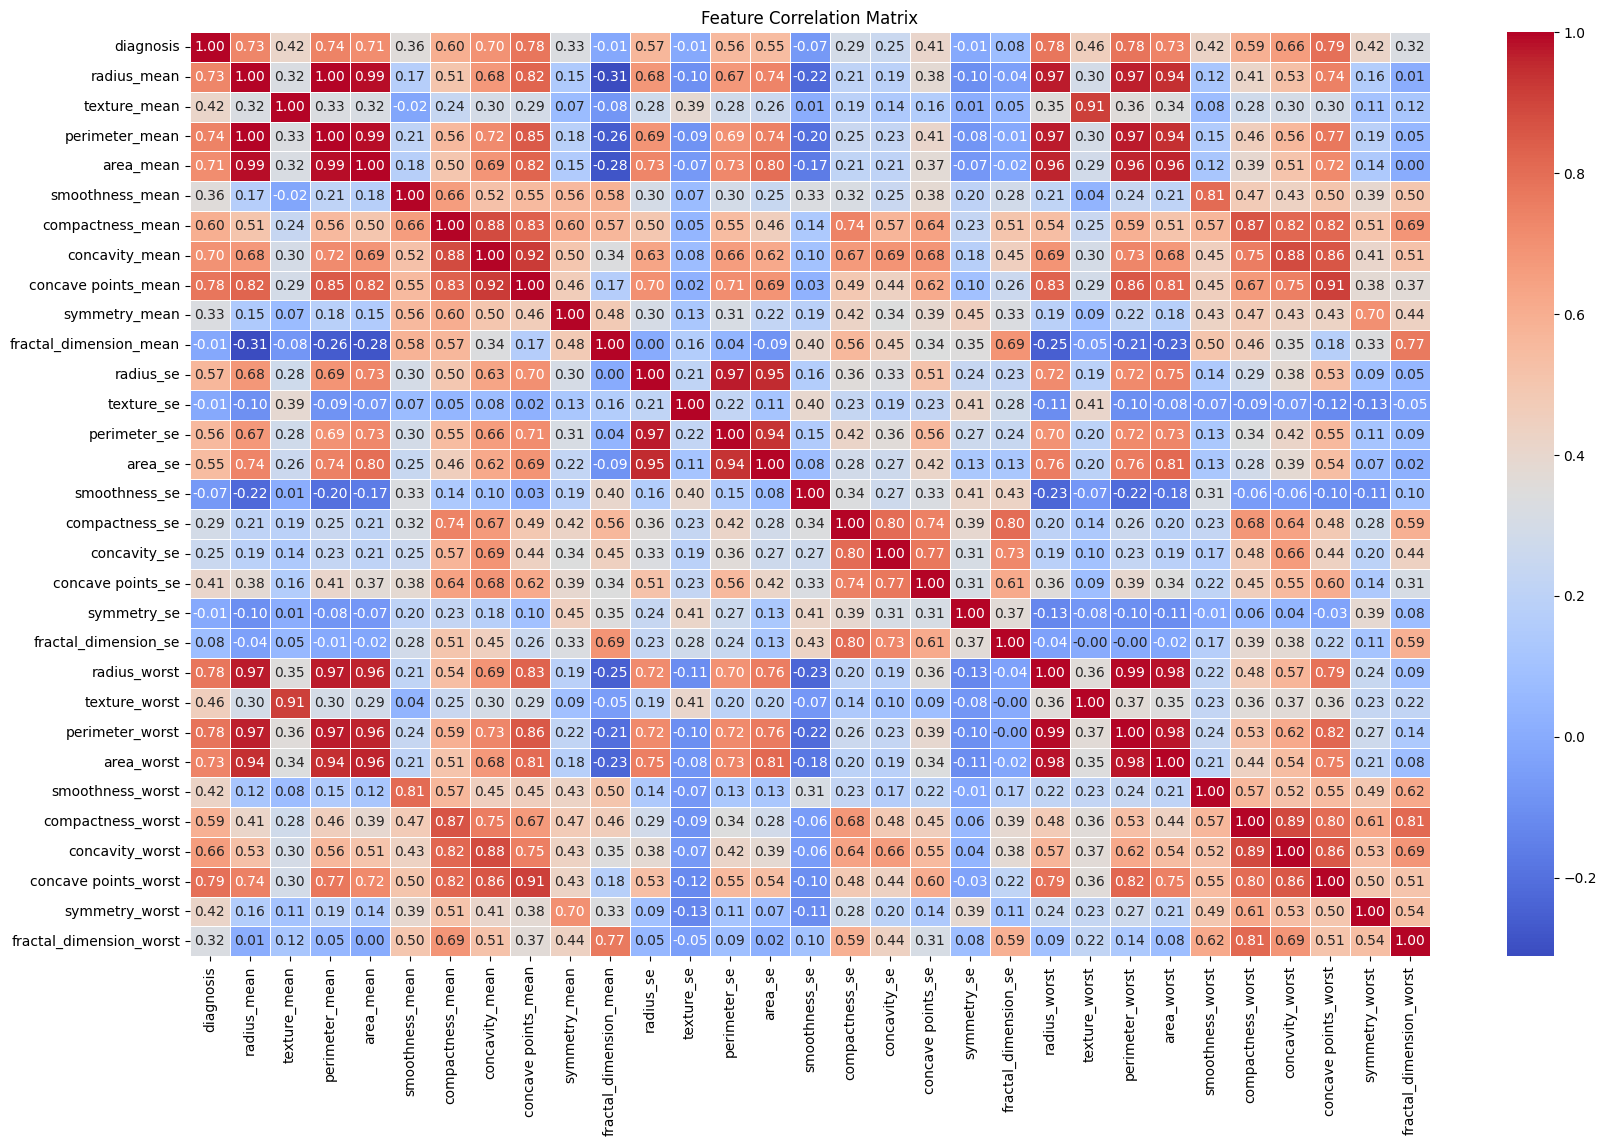

In [83]:
plt.figure(figsize=(20, 12))

corr_matrix = df.corr()

sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            linewidths=0.5)

plt.title('Feature Correlation Matrix')
plt.show()

### Data Partitioning: Train-Test Split

In [84]:
# Divide data into features and target
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

In [85]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=33)
X_train.shape

(426, 30)

### Feature Standardization

In [86]:
# Standardize the features

# Initialise the standardscaler module
scaler = StandardScaler()

# fit_transform X_train and transform X_test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Model Training

In [87]:
# Create the logistic regression model
lr = LogisticRegression()

# Train the model on training data
lr.fit(X_train_scaled, y_train)

# Predict the targets based on the test data
y_pred = lr.predict(X_test_scaled)

#### Model Evaluation

In [88]:
# Assess with classification metrics

print(f"Accuracy for the lr model: {(accuracy_score(y_test, y_pred)) :.2f}")
print(f"\nClassification report: ")
print(classification_report(y_test, y_pred))

Accuracy for the lr model: 0.99

Classification report: 
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        89
           1       1.00      0.96      0.98        54

    accuracy                           0.99       143
   macro avg       0.99      0.98      0.99       143
weighted avg       0.99      0.99      0.99       143



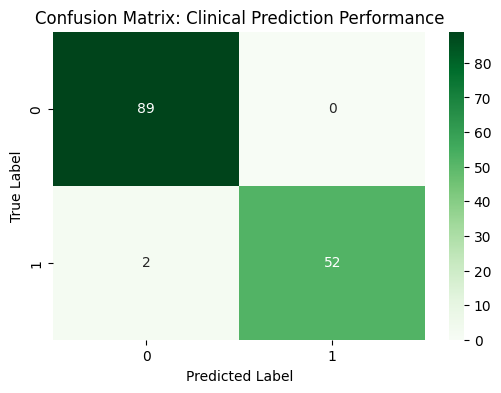

In [89]:
# Visualising the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Clinical Prediction Performance')
plt.show()

#### Model Interpretability: Analyzing Feature Importance through Coefficients

In [97]:
lr.coef_

array([[ 0.41786311,  0.24547317,  0.42514441,  0.4785754 ,  0.13976574,
        -0.29899537,  1.00061591,  0.94600795,  0.04672625, -0.52296327,
         0.68404208, -0.65034826,  0.30216919,  0.7010128 ,  0.37289112,
        -0.47271013,  0.05335003, -0.02474083, -0.09061872, -0.61921873,
         1.13902307,  1.59126687,  0.99273068,  1.07567489,  0.81835946,
        -0.1648722 ,  0.68868264,  1.03981336,  0.69301891,  0.22209388]])

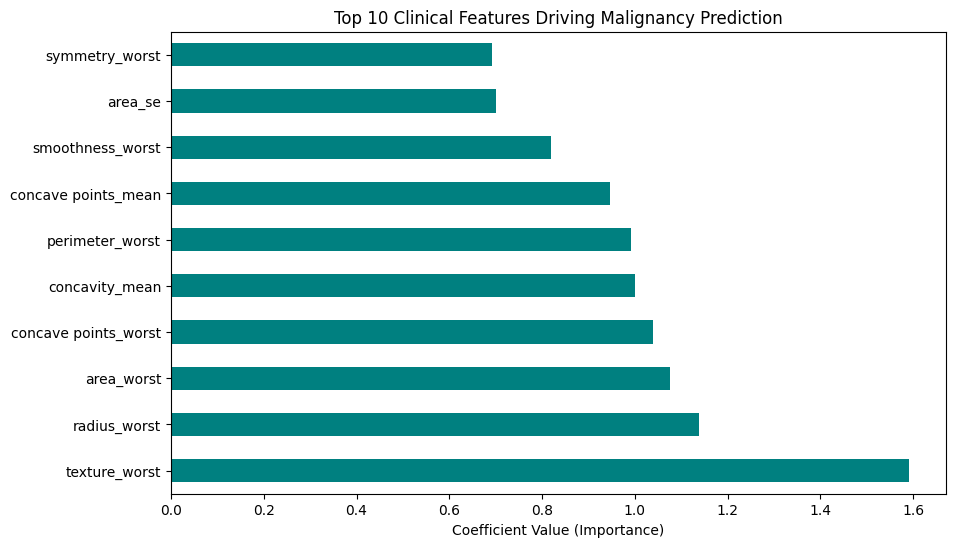

In [99]:
# Get coefficients
coefficients = lr.coef_[0]
feature_importance = pd.Series(coefficients, index=X.columns).sort_values(ascending=False)

# Plot top 10 features
plt.figure(figsize=(10,6))
feature_importance.head(10).plot(kind='barh', color='teal')
plt.title('Top 10 Clinical Features Driving Malignancy Prediction')
plt.xlabel('Coefficient Value (Importance)')
plt.show()